# Genome Assembly

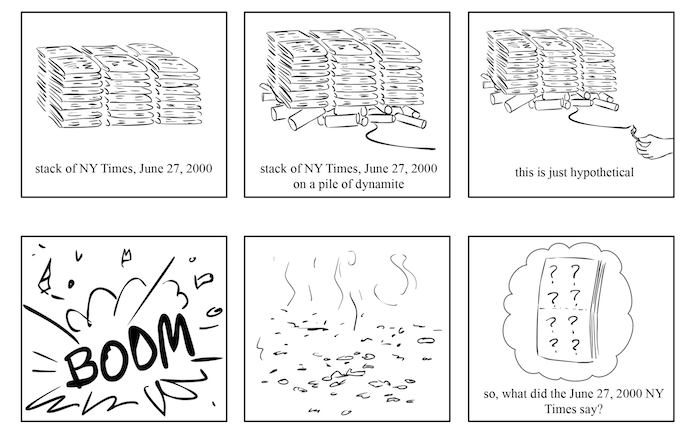





## Overview:
Genome Sequencing is difficult. We cannot simply read from one end of a chromosome to another (at least not yet). **So instead we must cut each chromosome into many small pieces and sequence the individual parts.** Reconstructing the original chromosomes using the small pieces is called Genome Assembly.

Just like we can find overlapping parts in the newspaper scraps, we assemble the original genome by finding overlapping sequences in each read. Then we just read the entire sequence from left to right.

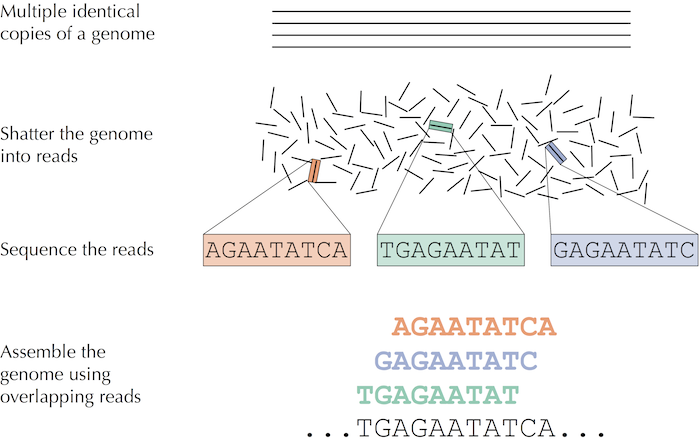

Although this process seems simple, there are a few wrinkles which complicate the process:

1. DNA is double stranded so the overlapping sequences may be on opposite strands-we have to deal with reverse compliment sequences.
2. Sequencing is not perfect and errors are still common.
3. Some regions of the genome may not be covered by any reads.

Though for our excercises we're mostly going to ignore these problems. We can pretend that there are no missing segments or errors in our sequences and that all sequences are on the same strand.

## Python functions and dictionaries

Given that we can store strings in Python, we can actually store different data types that are related to one another with a dictionary.

For each entry in a dictionary we have 2 pieces: a key and a value. The key is an identity or the name of a location. The value is what is stored at that location and is returned when using the key. In a dictionary the key is a word and the value is the definition, you get by navigating to the location of the key in the book.

In other programming languages dictionaries are called *hashmaps*. They are very fast but can occasionally take a lot of space in memory.

Here is a [quick tutorial on dictionaries](https://www.w3schools.com/python/python_dictionaries.asp) and below is a quick summary.

---

What if we wanted to print the name and first 3 letters of each students major in the example below.

This can be completed using [fstrings](https://www.geeksforgeeks.org/formatted-string-literals-f-strings-python/) or [string concat-ing](https://www.geeksforgeeks.org/python-string-concatenation/)

In [ ]:
# Example: Let's say you want to store a list of students & their majors
students = {
    "Joe": "Biology",
    "Anna": "Psychology",
    "Bob": "History"
}

# How would I print the name and major of just one student:
name_and_3let_major_string = ""
print(name_and_3let_major_string)

Instead of repeating it three times (once for each student), what if we wrote a function and a for loop. We'll start with the function:

In [ ]:
def name_and_major(dictionary, key):
    """
    Return the name and 3 letter major string from the dictionary for a given key
    """
    name_and_3let_major_string = ""
    # TODO
    return name_and_3let_major_string

# Test case for function
print(name_and_major(students, "Joe"))



Now let's try using the function with a for loop.

Hint: The test case above shows how to call your function.

In [ ]:
for key in students.keys():
    name_and_major(students, key)

## Kmer Introduction
Kmers are short DNA sequences of a given length that we can use to construct a DNA sequence.

For example given the sequence `CAATCCAAC`. The first 5-mer present would be `CAATC`, the second `AATCC` and so on. These kmers let us represent a longer sequence as the composition of many smaller pieces of length k.

If we can imagine the cut-up pieces of DNA during sequencing as kmers in the genome we might be able to see how algorithms with kmers could be useful for genome assembly. In fact, kmers are fundamental to many bioinformatic algorithms.

---

Let's practice generating them.

hint: a `for` loop and string slicing should be enough to solve this problem.

In [ ]:
def kmer_composition(text: str, k: int) -> list[str]:
    """
    This function should return a list containing all kmers of length k from text
    """
    kmers = []
    # TODO
    for i in range(len(text)-k+1):
        kmers.append(text[i:i+k])
    return kmers


In [ ]:
# Check you solution here
k = 5
text = "CAATCCAAC"
correct_output = ["CAATC", "AATCC", "ATCCA", "TCCAA", "CCAAC"]
computed_output = kmer_composition(text, k)

if len(correct_output) is not len(computed_output): raise Exception("Wrong number of kmers")
for kmer in correct_output:
    if kmer not in computed_output:
        raise Exception(f"Missing kmer: {kmer}")
print("Success!")

My solution:

In [ ]:
#@title My solution
def kmer_composition(text: str, k: int) -> list[str]:
    """
    This function should return a list containing all kmers of length k from text
    """
    kmers = []
    for i in range(len(text)-k+1):
        kmers.append(text[i:i+k])
    return kmers

In [ ]:
# What should the output of the function be?
kmer_composition("AATCGATC", 3)

## Does aligning kmers always work?

Given our set of kmers, one way to reconstruct our original sequence is to notice their overlaps. In the previous example our contigs overlap as shown:

``` python
CAATC
 AATCC
  ATCCA
   TCCAA
    CCAAC
```
Each column corresponds to a single nucleotide and we can reconstruct the sequence by reading from left to right.

``` python
CAATCCAAC
```


More concretely, each k-mer is made up of a **prefix** and a **suffix** each of length k-1. Then overlap between k-mers A and B is equivalent to saying the suffix of k-mer A is identical to the prefix of k-mer B.

For example let kmer_A and kmer_B be defined below:
``` python
kmer_A = "CAATC"
kmer_B = "AATCC"
```

What is the prefix and suffix of kmer_A? kmer_B?

In [ ]:
# TODO: insert answers here
kmer_A_prefix = ""
kmer_A_suffix = ""

kmer_B_prefix = ""
kmer_B_suffix = ""

Which of the following statements will print True?

In [ ]:
print("Case A:", kmer_A_prefix == kmer_B_prefix)
print("Case B:", kmer_A_prefix == kmer_B_suffix)
print("Case C:", kmer_A_suffix == kmer_B_prefix)
print("Case D:", kmer_A_suffix == kmer_B_suffix)

NameError: name 'kmer_A_prefix' is not defined

Now try assembly in practice to get an intuition for our goal.

Consider this set of 3-mers. Take a few minutes and try to reconstruct the original sequence. Type your answer below.
``` python
AAT AAT ATG ATT GAA TAA TGA TTA
```

Try adding in the overlapping segments here like we saw before:
``` python
# TODO:
AAT
 ATG
  TGA
   GAA
    AAT
     ATT
      TTA
       TAA
   ...

# Solution:
```

In [ ]:
#TODO hide solution
original_seq = "TAATGAATTA"

You may notice that connecting the overlapping pieces doesn't always work. Consider this example:
``` python
TAA
 AAT
  ATT
   TTA
```
After assembling 4 kmers we find that there is no kmer that we can add after TTA. This is because one k-mer, AAT, is repeated twice. We have to guess the correct kmer to follow afterward in either ATG or ATT.

Recall our genomes are made up of millions of repeated segments. To test every possible combination is an extremely slow task, even with modern computing power.

Instead we must come up with a more clever approach to solve this problem.

## Graph introduction

## What is a graph?

In computer science a graph is just a set of nodes and edges. For example, the following graph contains three nodes and two edges. The set of nodes and edges might be defined as follows:
``` python
nodes = [0, 1, 2]
edges = [(0,1), (1,2)]
```


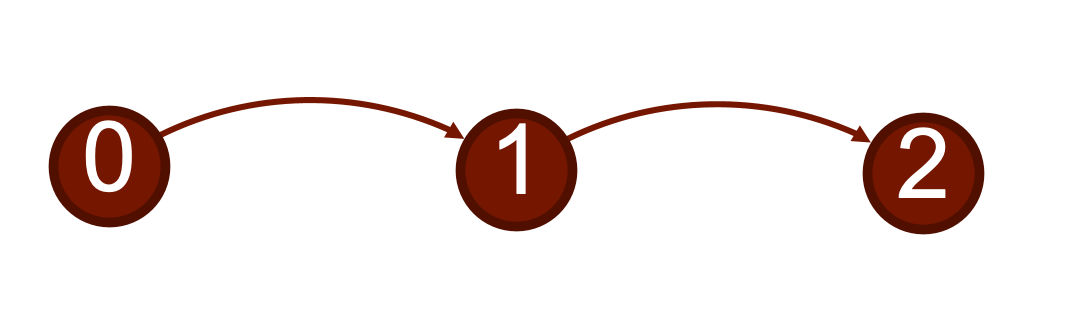


Notice here that the direction of the edges matter. The edge (1,2) is not the same as (2,1). This called a *directed graph* or *digraph*.

There are two properties additional properties of nodes in a digraph called the *in-degree* and *out-degree*. The in-degree is the number of edges that point to a node, the out-degree is the number of edges that leave a node.

Consider the example below:
1. What edges and nodes are different between the above and below graphs
2. What is the in and out degree of each node? Answer in the table below:

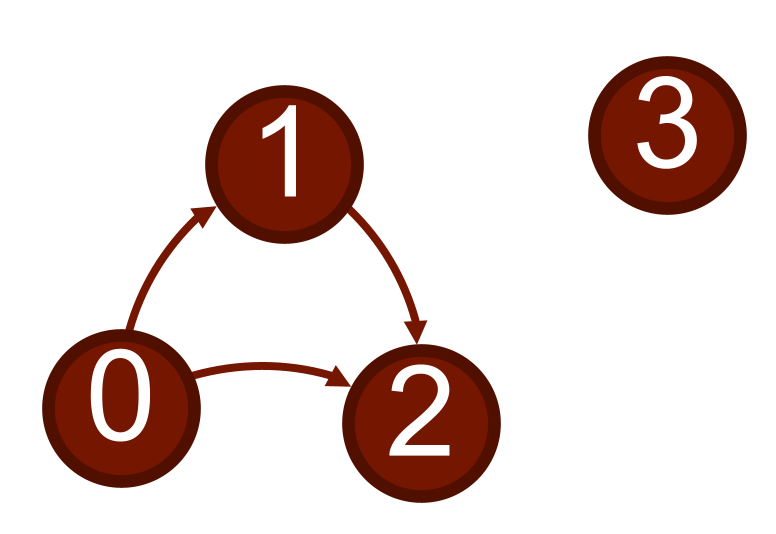

**Complete table below:**
| Node ID | In-degree | Out-degree |
| --- | ---------- | ---------- |
| 0 | ? | ? |
| 1 | ? | ? |
| 2 | ? | ? |
| 3 | ? | ? |

We typically represent graphs in python using dictionaries (though there are many valid choices).

Consider the first graph as a python dictionary below.
```python
simple_graph = { 0:[1], 1:[2], 2:[]}
```
Each starting node is a key in our dictionary. All of the nodes its edges touch are stored in a list.
Write the python representation of the second graph below:

In [ ]:
simple_graph2 = {0:[1,2], 1:[2], 2:[], 3:[]}

## Overlap Graphs

An overlap graph allows us to model the relationships between overlapping kmers and will help us efficiently finding the original genome.

Recall the sequence from above and it's 5mers
```
CAATC
 AATCC
  ATCCA
   TCCAA
    CCAAC
CAATCCAAC
```

In the overlap graph of this sequence each 5mer is a node, and when k-1 characters overlap, we draw an edge between them. This sequence is represented in the graph below. Notice how we can travel a path between nodes following the edges and recover the entire sequence, this is exactly what we want for genome assembly!



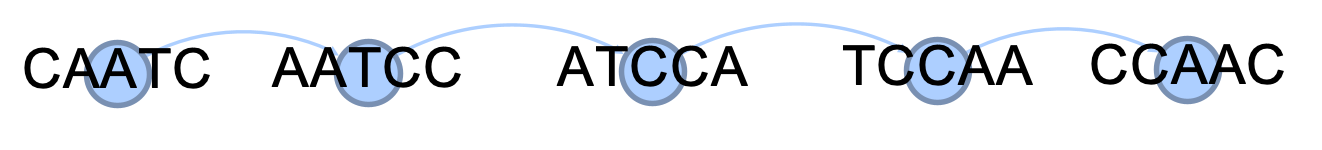

But if a kmer shares an overlap with 2 sequences. Consider the same sequence as before but we preprend a `C` to get `CCAATCCAAC`. We add one new 5mer to our set: `CCAAT`. The overlap graph of this sequence becomes considerably more complicated.

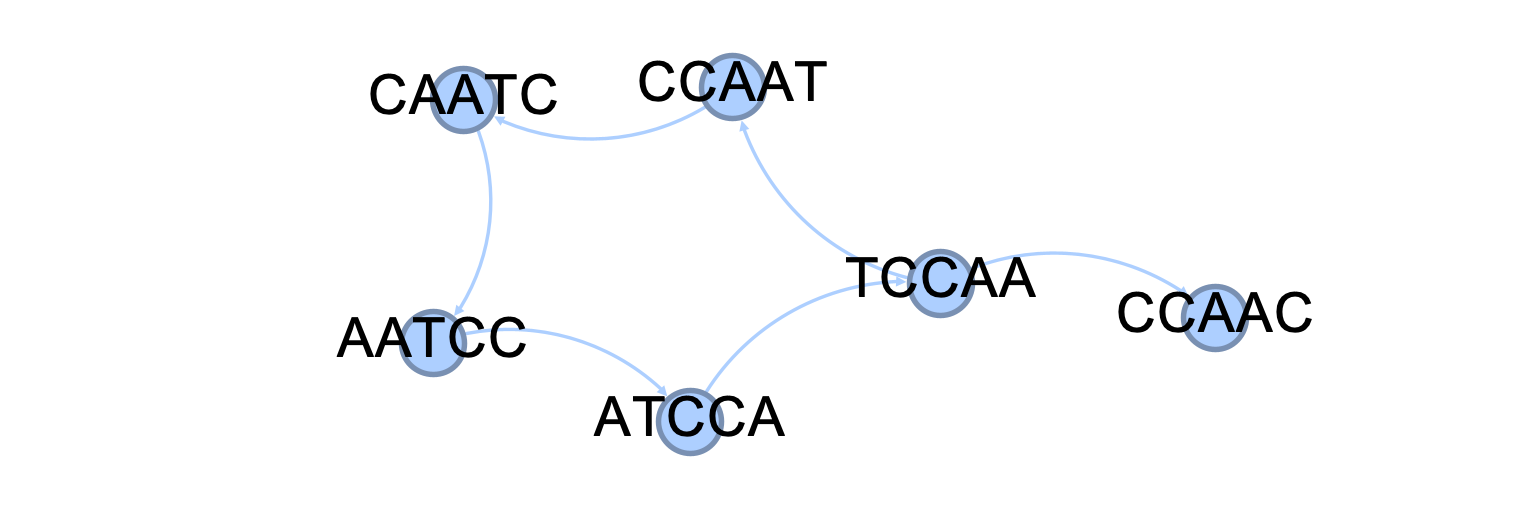

It turns out that overlap graphs are not enough to solve our problem, we need one more tool.

## de Bruijn graphs

A de Bruijn graph is identical to an overlap graph except whenever we have duplicate nodes we combine them. Consider the overlap graph on the left which contains several nodes labeled `TG`. To generate the de Bruijn graph we simply merge them into one node and keep all 3 edges. It turns out that this is the correct kmer representation to reconstruct our original genome.

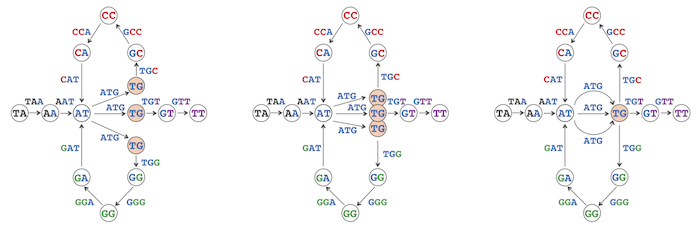

Even though we introduced de Bruijn graphs from overlap graphs. We can construct them directly from a set of kmers. We don't need the original sequence at all. Because we no longer add a node for each kmer, the construction pseudocode is just one line:

`For each kmer, add an edge from its prefix to its suffix to our graph.`

For example:
``` python
de_bruijn_graph = defaultdict(list)
kmer = "ACGT"
de_bruijn_graph["ACG"].append("CGT")
```

Try implementing a function to build a de Brujin graph from a list of kmers. I've started the function below for you:

In [ ]:
from collections import defaultdict

In [ ]:
def build_de_bruijn(kmers:list[str]) ->  dict[str, list[str]]:
    de_bruijn_graph = defaultdict(list)
    for kmer in kmers:
        pass
        de_bruijn_graph[kmer[1:]] = (kmer[:-1])
    return de_bruijn_graph

In [ ]:
"""
Input kmers from ACGTGTATA with k=3
Example goal edge list:
AC: CG
AT: TA
CG: GT
GT: TA TG
TA: AT
TG: GT
"""
input_kmers = ["ACG", "CGT", "GTG", "TGT", "GTA", "TAT", "ATA"]
graph = build_de_bruijn(input_kmers)
print(graph)


defaultdict(<class 'list'>, {'CG': 'AC', 'GT': 'TG', 'TG': 'GT', 'TA': 'AT', 'AT': 'TA'})


In [ ]:
#@title My solution
def build_de_bruijn(kmers:list[str]) ->  dict[str, list[str]]:
    de_bruijn_graph = defaultdict(list)
    for kmer in kmers:
        de_bruijn_graph[kmer[1:]] = kmer[:-1]
    return de_bruijn_graph

## Finding genomes in de Bruijn graphs

After constructing a De Bruijn graph of kmers from your genome, we can reconstruct the original genome sequence by finding a Eularian Path in the graph. A Eulerian Path is a trail in the graph that visits every edge exactly once, and has a start and end node.

An easy way to tell whether a graph contains an Eularian cycle or not is if by looking at the degree of each node in the graph has. Because we have constructed a directed graph, we can look at the number of edges pointing towards the node as the in degree of the node, and the number of edges pointing from that node as the out degree of the node.


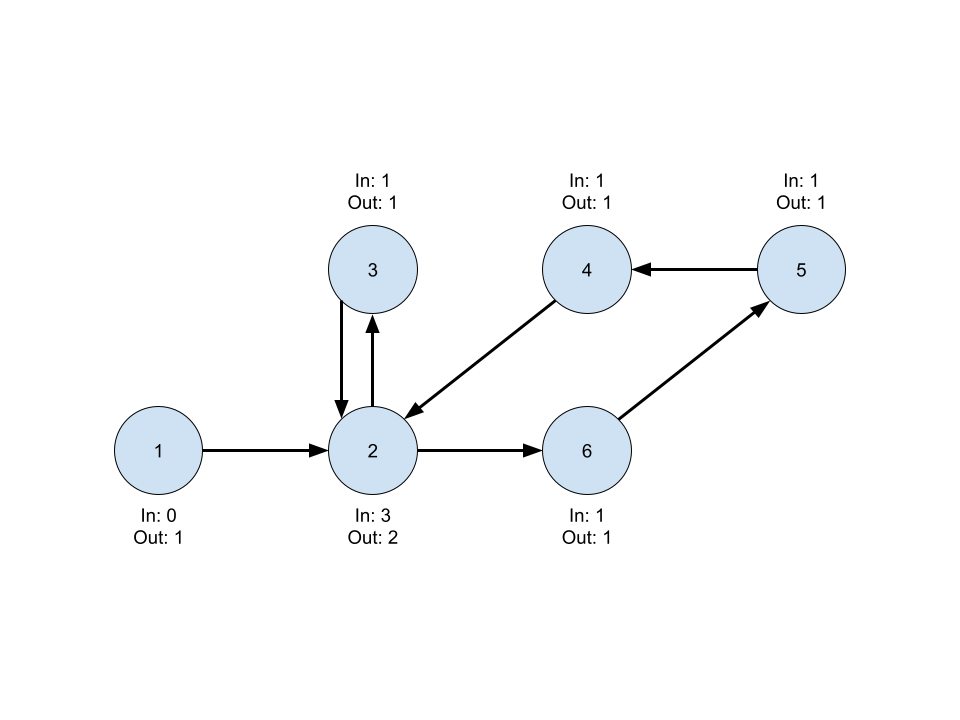

In this example, each node is written with the in and out degrees for every node. Now, we know if an Eulerian Path exists because every node in the cycle must have the same in degrees as out degrees, unless it is the start and end node. The start and end node can differ by one degree, thus having an odd number of paths (start node -> out degrees = in degrees + 1, end node -> in degrees = out degrees + 1).

Some graphs may have every node as having the same in degree and out degree. This would mean the graph contains a Eulerian Cycle, where the node where the cycle starts is also the node where it ends.

Try writing a function to calculate the in and out degrees of all nodes in a graph.

In [ ]:
def find_in_out_degrees(de_bruijn_graph) -> tuple[dict, dict]:
    in_degrees = defaultdict(int)
    out_degrees = defaultdict(int)

    # TODO: Fill in and out degrees
    for node in de_bruijn_graph:
        out_degrees[node] = len(de_bruijn_graph[node])
        for neighbor in de_bruijn_graph[node]:
            in_degrees[neighbor] += 1

    return in_degrees, out_degrees

Example from above graph:

in_degrees = {"1": 0, "2": 3, "3": 1, "4": 1, "5": 1, "6": 1}

out_degrees = {"1": 1, "2": 2, "3": 1, "4": 1, "5": 1, "6": 1}

start node: 1

end node: 2

In [ ]:
#@title My solution for in/out degrees and calculating start/end nodes

# Implement find start node & end node
def find_in_out_degrees(de_bruijn_graph) -> tuple[dict, dict]:
    #dictionaries for keeping track of in degrees and out degrees for each node
    in_degrees = defaultdict(int)
    out_degrees = defaultdict(int)

    # TODO: populate in_degrees and out_degrees dictionaries
    for node in de_bruijn_graph:
        out_degrees[node] = len(de_bruijn_graph[node])
        for neighbor in de_bruijn_graph[node]:
            in_degrees[neighbor] += 1

    return in_degrees, out_degrees


# We can then calculate the start and end nodes by finding the nodes with
# mismatched in and out degrees.
def find_start_end_nodes(in_degrees, out_degrees, de_bruijn_graph):
    end_node = None
    start_node = None
    # (make sure to handle edge cases for faulty graph or eulerian cycle)
    for node in de_bruijn_graph:
        in_degree = in_degrees[node]
        out_degree = out_degrees[node]

        if abs(out_degree - in_degree) > 1:
            return None, None
        if out_degree - in_degree == 1:
            # found potential start node in path
            if start_node != None:
                # already found start node, cannot have more
                return None, None
            start_node = node
        if in_degree - out_degree == 1:
            # found potential end node in path
            if end_node != None:
                # already found start node, cannot have more
                return None, None
            end_node = node

    if start_node == None and end_node == None:
        return list(de_bruijn_graph.keys())[0], list(de_bruijn_graph.keys())[0]

    return start_node, end_node

Now, we can use Heirholzer's algorithm to discover this Eulerian Path. So far we have assigned each node an in and out degrees, as well as identified a start and end node for the graph. We need to construct a traversal that visits all edges in the graph. To keep track of unvisited edges each node has, we can use the out degrees computed for each node and update them whenever a path has been visited. Then, we can follow a trail of nodes starting from our start node, updating our out degrees table as we go. Once we reach a dead end at a node where all out going edges have been visited, we can backtrack from that node to visit any remaining unvisited outgoing edges at other nodes.

We can use the eulerian_path function in the networkx library to implement the search for Eulerian cycles.

In [ ]:
# Getting the Eulerian path

import networkx as nx

def find_eulerian_path(graph):
    # convert the dictionary to a DiGraph
    G = nx.DiGraph(graph)

    # check if the graph has Eulerian path
    if not nx.has_eulerian_path(G):
        print("No Eulerian path exists in the graph.")
        return None

    # find the Eulerian path
    eulerian_path = list(nx.eulerian_path(G))
    return eulerian_path

# example graph
graph = {
    'A': ['B'],
    'B': ['C'],
    'C': ['A'],
    'D': ['B']
}
in_degrees, out_degrees = find_in_out_degrees(graph)
start, end = find_start_end_nodes(in_degrees, out_degrees, graph)
print("Start: ", start)
print("End: ", end)

path = find_eulerian_path(graph)
if path:
    print("Eulerian Path:", path)


Start:  D
End:  B
Eulerian Path: [('D', 'B'), ('B', 'C'), ('C', 'A'), ('A', 'B')]


## Addendum: assembly in practice

Assembly in reality is much more difficult than we have illustrated here because we made several simplifying assumptions.

Firstly, to reconstruct a genome by traversing a de Bruijn graph we assumed that all kmers of our original sequence are present. But in reality our reads are not evenly distributed. In the figure below we can see that even though the sequenced 10-mers cover the entire sequence, they are too sparse to use the method we've described above. To accomodate for this problem we can break the 10-mers into smaller k-mers. These smaller 5-mers cover every possible 5-mer in our sequence so our assembly method works.

However, this is not a catch-all. When lowering our k, we are more likely to see repetitive sequences and this can make multiple correct solutions possible. So we want to maintain as high k as possible while covering all k-mers in the dataset.


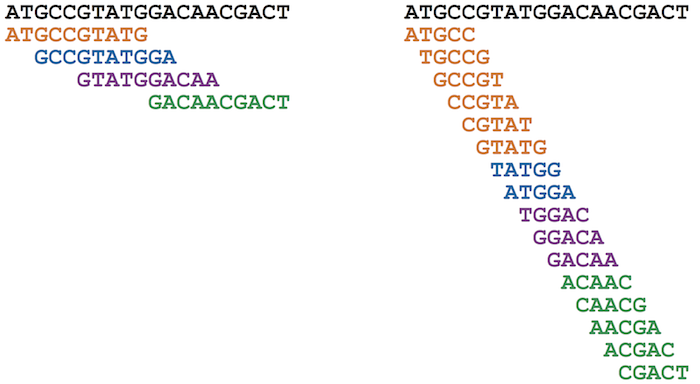

Secondly, we assumed that there were no errors in any of our reads. An error in a read produces a *bubble* in our overlap graph as shown below. Modern assemblers will try to detect these bubbles in de Bruijn graphs collapse them to the correct path based on the number of reads that support each variation. We can predict the size of bubbles based on which k we choose to better detect erroneous reads.

But it's not a perfect process and errors do occasionally make thier way into assemblies.

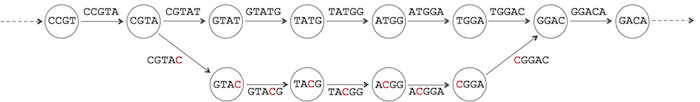

We also assumed that there are no gaps in our reads coverage of the genome. This is very rarely the case. In this scenario we cannot generate a sequence that is not present in our data. So in practice, we must settle for the longest contigous sequences possible, these are often called **contigs**. Fortunately these can also be found efficiently in the de Bruijn graph as *maximal non-branching paths*. Each non-branching path corresponds to a sequence that we are 100% sure exists as a real sequence in the genome because it has no ambiguity on which path it follows.

Each contig must exist as a real contiguous sequence on one chromosome, but the contigs could exist very far apart from each other or on different chromosomes entirely. We can scaffold these contigs together into an assembly with gaps using outside information or different sequencing technologies (Hi C, Long Read, paired-end).

The complete human genome published in 2000 was such an assembly with gaps comprising ~8% of all bases. The real gapless human genome was only completed in 2022.

In practice sequencing is often done with paired-end reads. This allows us to know that two sequences are a fixed distance apart from each other. In many cases, we can use this information to eliminate incorrect, but possible assemblies from the real contig that exists in the organism.

We assumed that all reads were on the same strand of our double stranded DNA. In reality, we sequence from both strands of DNA and have no way to determine which is which. Our solution is to add the reverse-compliment of every read into our dataset, effectively doubling the number of reads. This complicates assembly but allows to include all information from sequencing.

This extra complexity in our de Bruijn graph is not random. Certain characteristic features appear such as palindromes and we can simplify our graph without losing information to better handle the influx of reads. This combined with paired-end reads still allows us to find contigs effectively.